### Training convergence with confidence intervals

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plot_utils import plot_convergence_ci

from utils.analyse_results import GraphsTraining, Results, ConvergenceCI

train_info = GraphsTraining()

### Pyomo results sample

In [3]:
fp = "results/pyomo/2025-10-26_14-49_ho_conv_time_1_seeds.pkl"
results_li = Results.load_results(fp)
results_df = Results.flatten_convergence_data(results_li, key_list=["system", "pretrain", "max_t"], model_type="pyomo")
results_df

,system,pretrain,max_t,time_elapsed,mse_train,mse_test,termination,seed
0,ho,True,0.01000,0.148786,21.444899,10.117250,maxIterations,0
1,ho,True,0.44688,0.548411,0.008288,0.005297,maxIterations,0
2,ho,True,1.75750,1.674454,0.006127,0.003548,optimal,0


### Pytorch results sample

In [4]:
fp = "results/pytorch/2025-10-26_17-40_ho_conv_time_3_seeds.pkl"
results = Results.load_results(fp)

In [5]:
fp = "results/pytorch/2025-10-26_17-40_ho_conv_time_3_seeds.pkl"
results_li = Results.load_results(fp)
results_df = Results.flatten_convergence_data(results_li, key_list=["system", "pretrain", "max_t"], model_type="pytorch")
results_df

,time_elapsed,mse_train,mse_test,system,pretrain,max_iter,seed
0,19.275354,1.438995,1.573132,ho,True,"[400, 400]",0
1,19.394255,1.313921,1.459574,ho,True,"[400, 400]",0
2,19.513156,1.180789,1.335131,ho,True,"[400, 400]",0
3,19.632056,1.050850,1.209176,ho,True,"[400, 400]",0
4,19.750957,0.930256,1.087509,ho,True,"[400, 400]",0
...,...,...,...,...,...,...,...
395,69.558307,0.003367,0.004561,ho,True,"[400, 400]",2
396,69.681578,0.003345,0.004517,ho,True,"[400, 400]",2
397,69.804848,0.003323,0.004474,ho,True,"[400, 400]",2
398,69.928118,0.003301,0.004431,ho,True,"[400, 400]",2


<Axes: xlabel='Training Time (s)', ylabel='Training MSE (log scale)'>

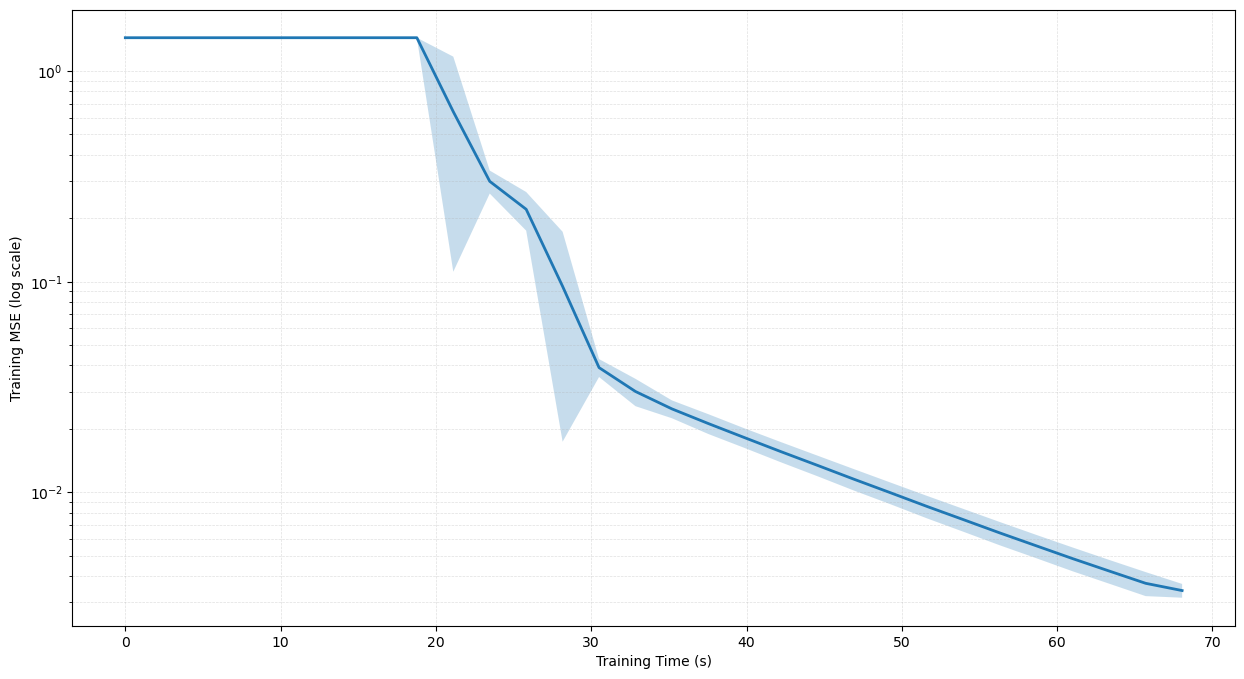

In [8]:
# currently slicing on two metrics pretrain & system
x_grid, mean, lo, hi, Y = ConvergenceCI.time_ci(results_df, system = "ho", pretrain=True, ci = "t", grid_points=30, tmax_quantile=0.7)
plt.figure(figsize=(15,8))
plot_convergence_ci(x_grid, mean, lo, hi, label="Pytorch")

In [ ]:
# fp_no_pretrain = "results/pytorch/2025-10-26_15-54_ho_conv_time_3_seeds.pkl"
# results = Results.load_results(fp_no_pretrain)

In [64]:
fp = 'results/pyomo/2025-10-19_16-59-45_ho_conv_15_seeds.pkl' # 32 neurons
fp = "results/pyomo/2025-10-21_20-33-45_ho_conv_time_15_seeds.pkl" # wall-time
fp = "results/pyomo/2025-10-24_21-36-59_ho_conv_time_1_seeds.pkl"
fp = "results/pyomo/2025-10-25_11-15-33_ho_conv_time_1_seeds.pkl"
fp = "results/pyomo/ho_conv_time_20_seeds_2_16_2.pkl"

results_li = Results.load_results(fp)

results_df = Results.flatten_convergence_data(results_li, key_list=["system", "pretrain", "max_t"])

results_df.head()

,system,pretrain,max_t,time_elapsed,mse_train,mse_test,termination,seed
0,ho,True,0.01000,0.155685,2.678107,1.540646,maxIterations,0
1,ho,True,0.01593,0.151796,2.678107,1.540646,maxIterations,0
2,ho,True,0.03373,0.155369,2.678107,1.540646,maxIterations,0
3,ho,True,0.06340,0.155916,2.678107,1.540646,maxIterations,0
4,ho,True,0.10493,0.212161,0.682094,1.409008,maxIterations,0


<Axes: xlabel='Training Time (s)', ylabel='Training MSE (log scale)'>

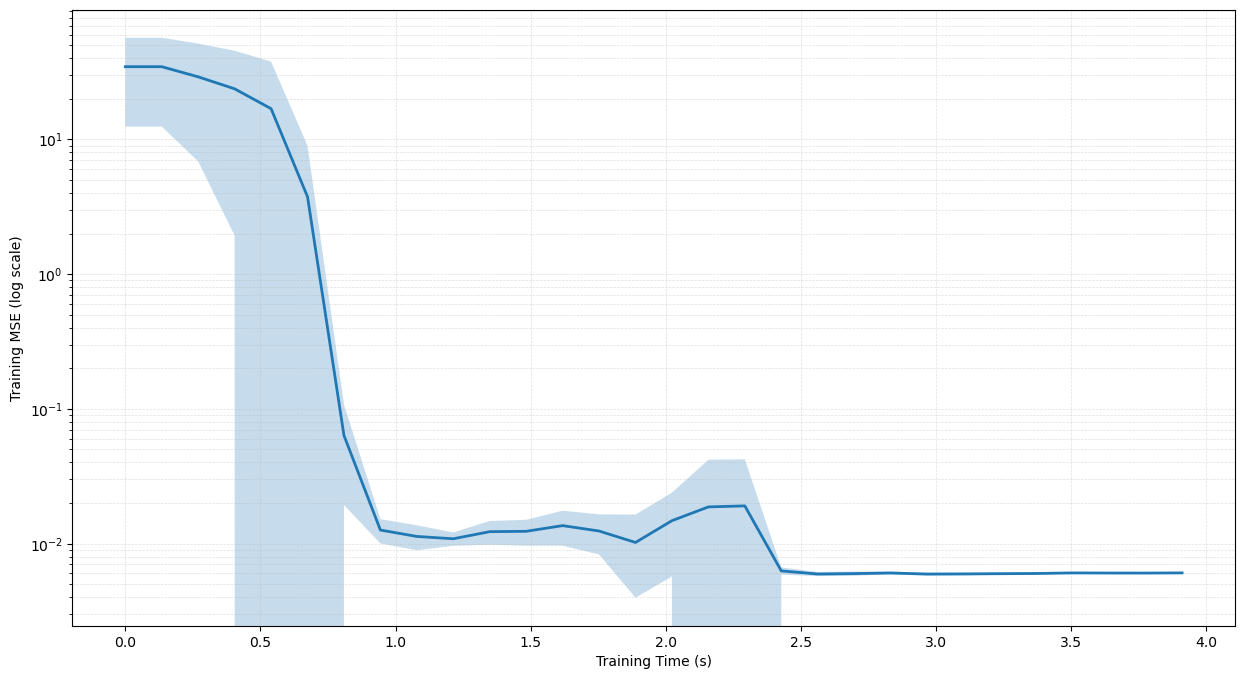

In [ ]:
# currently slicing on two metrics pretrain & system
x_grid, mean, lo, hi, Y = ConvergenceCI.time_ci(results_df, system = "ho", pretrain=True, ci = "t", grid_points=30, tmax_quantile=0.7)
plt.figure(figsize=(15,8))
plot_convergence_ci(x_grid, mean, lo, hi, label="Pyomo")

<Axes: xlabel='Training Time (s)', ylabel='Training MSE (log scale)'>

<Figure size 1500x800 with 0 Axes>

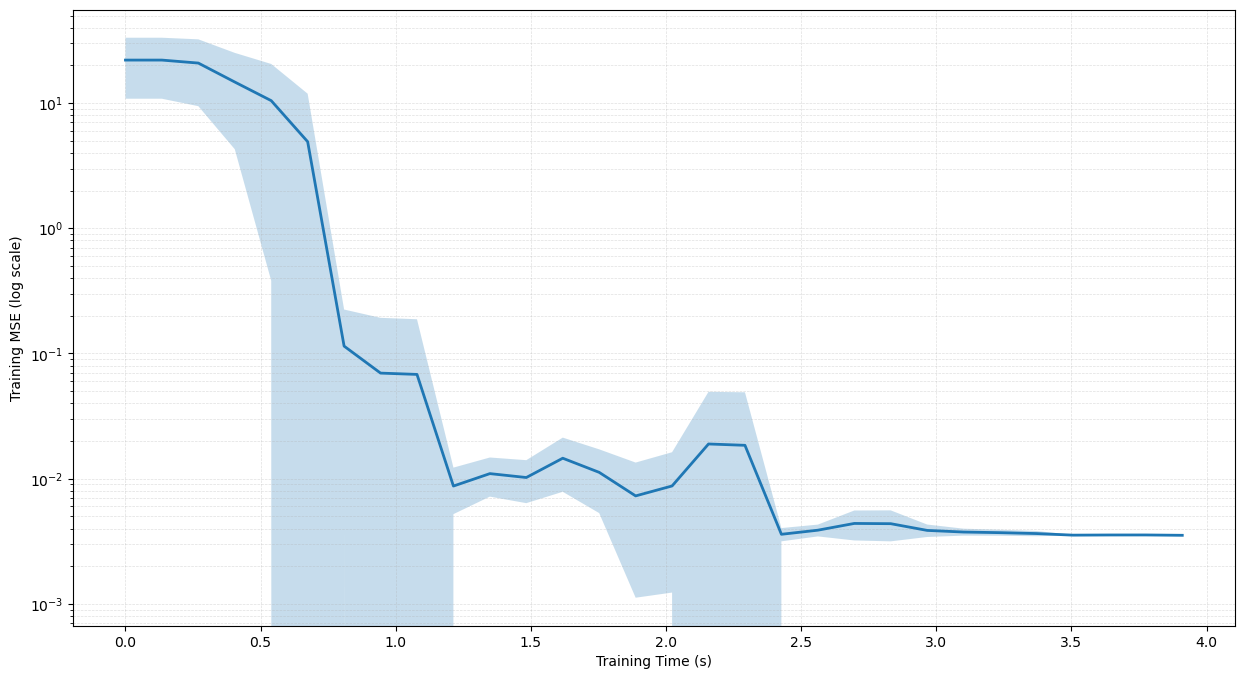

In [34]:
plt.figure(figsize=(15,8))
x_grid, mean, lo, hi, Y = ConvergenceCI.time_ci(results_df, system = "ho", pretrain=True, ci = "t", grid_points=30, y_col="mse_test", tmax_quantile=0.7)
plt.figure(figsize=(15,8))
plot_convergence_ci(x_grid, mean, lo, hi, label="Pyomo")